
=== 特征简介 ===
PassengerId: 乘客ID
Survived: 是否获救 (0: 否, 1: 是)
Pclass: 客舱等级 (1/2/3)
Name: 乘客姓名
Sex: 性别
Age: 年龄
SibSp: 同乘兄弟姐妹/配偶数
Parch: 同乘父母/子女数
Ticket: 船票编号
Fare: 票价
Cabin: 客舱号
Embarked: 登船港口 (C=Cherbourg, Q=Queenstown, S=Southampton)

=== 特征提取 ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked Title  FamilySize  IsA

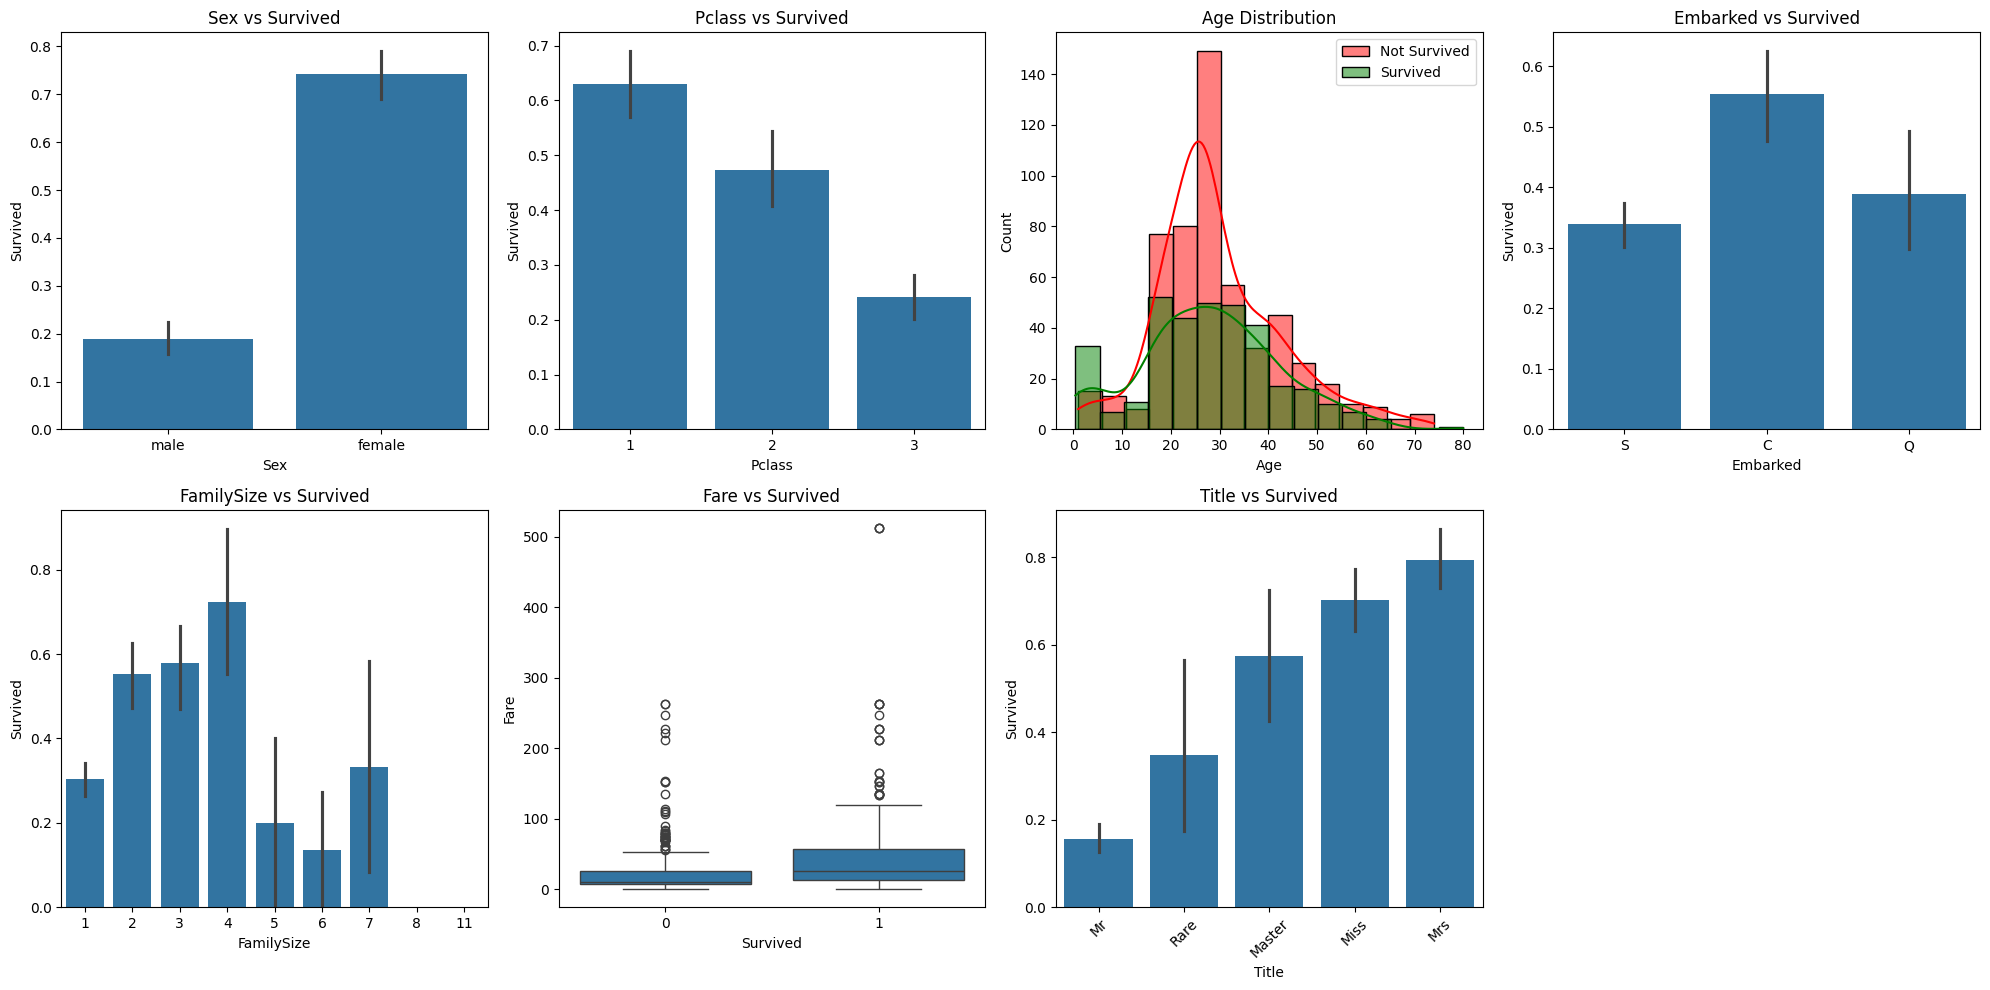


=== 特征归类处理 ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked Title  FamilySize  IsAlone  \
0      0         A/5 21171   7.2500   NaN        S    Mr           2        0   
1      0          PC 17599  71.2833   C85        C   Mrs           2        0   
2      0  STON/O2. 3101282   7.9250   NaN        S  Miss     

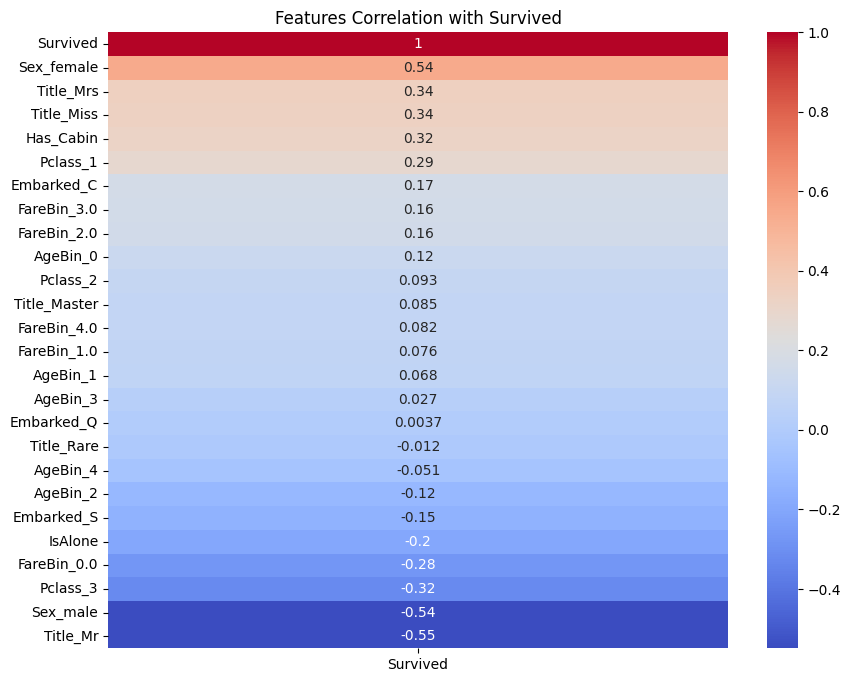

Title_Mr       0.337890
Sex_female     0.325596
Has_Cabin      0.100789
Pclass_1       0.082249
Title_Mrs      0.072455
IsAlone        0.041228
FareBin_2.0    0.039793
dtype: float64


In [6]:
# -*-coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 加载数据
data = pd.read_csv('train.csv')

# ======================
# i. 特征简介
# ======================
print("\n=== 特征简介 ===")
print("PassengerId: 乘客ID")
print("Survived: 是否获救 (0: 否, 1: 是)")
print("Pclass: 客舱等级 (1/2/3)")
print("Name: 乘客姓名")
print("Sex: 性别")
print("Age: 年龄")
print("SibSp: 同乘兄弟姐妹/配偶数")
print("Parch: 同乘父母/子女数")
print("Ticket: 船票编号")
print("Fare: 票价")
print("Cabin: 客舱号")
print("Embarked: 登船港口 (C=Cherbourg, Q=Queenstown, S=Southampton)")

# ======================
# ii. 特征处理步骤
# ======================

# 1. 特征提取
print("\n=== 特征提取 ===")

# Title处理
data["Title"] = data["Name"].str.extract(r' ([\w]+)\.', expand=False)
title_mapping = {
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
}
data["Title"] = data["Title"].replace(title_mapping)

# 创建家庭规模特征
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = 0
data.loc[data['FamilySize'] == 1, 'IsAlone'] = 1

# 处理缺失值
data['Age'] = data.groupby(['Pclass', 'Title'])['Age'].transform(lambda x: x.fillna(x.median()))
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Fare'] = data['Fare'].fillna(data['Fare'].median())
data['Has_Cabin'] = data['Cabin'].notnull().astype(int)
data['Cabin_Deck'] = data['Cabin'].str[0]  # 提取第一位字母（代表甲板）
data['Cabin_Deck'] = data['Cabin_Deck'].fillna('U')  # 'U' 表示未知

# describe
print(data.head())

# 2. 画图分析特征
print("\n=== 可视化分析 ===")
plt.figure(figsize=(20,10))

# 性别与生存率
plt.subplot(2,4,1)
sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Sex vs Survived')

# 船舱等级与生存率
plt.subplot(2,4,2)
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Pclass vs Survived')

# 年龄分布
plt.subplot(2,4,3)
sns.histplot(data[data['Survived']==0]['Age'], color='red', label='Not Survived', binwidth=5, kde=True)
sns.histplot(data[data['Survived']==1]['Age'], color='green', label='Survived', binwidth=5, kde=True)
plt.title('Age Distribution')
plt.legend()

# 登船港口与生存率
plt.subplot(2,4,4)
sns.barplot(x='Embarked', y='Survived', data=data)
plt.title('Embarked vs Survived')

# 家庭规模与生存率
plt.subplot(2,4,5)
sns.barplot(x='FamilySize', y='Survived', data=data)
plt.title('FamilySize vs Survived')

# 票价与生存率
plt.subplot(2,4,6)
sns.boxplot(x='Survived', y='Fare', data=data)
plt.title('Fare vs Survived')

# 头衔与生存率
plt.subplot(2,4,7)
sns.barplot(x='Title', y='Survived', data=data, order=data.groupby('Title')['Survived'].mean().sort_values().index)
plt.xticks(rotation=45)
plt.title('Title vs Survived')

plt.tight_layout()
plt.show()

# 3. 特征值归类处理
print("\n=== 特征归类处理 ===")
# 年龄分箱（转为分类类型）
data['AgeBin'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100], labels=False)
data['FareBin'] = pd.cut(data['Fare'], bins=[0, 10, 30, 100, 250, 600], labels=False)

print(data.head())

# 4. One-Hot编码（包含所有需要编码的特征）
print("\n=== One-Hot编码 ===")
all_features = ['Pclass', 'Sex', 'Embarked', 'AgeBin', 'FareBin', 'Title', 'Has_Cabin', 'IsAlone']
data_encoded = pd.get_dummies(data[all_features], columns=['Pclass', 'Sex', 'Embarked', 'AgeBin', 'FareBin', 'Title'])

print(data_encoded.head())

# ======================
# iii. 特征选择
# ======================
print("\n=== 特征选择 ===")
# 合并目标变量
data_encoded['Survived'] = data['Survived']
# 计算相关性
corr_matrix = data_encoded.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix[['Survived']].sort_values(by='Survived', ascending=False), 
            annot=True, cmap='coolwarm')
plt.title('Features Correlation with Survived')
plt.show()

# 选择关键特征
selected_features = [
    "Title_Mr", "Sex_female", "Has_Cabin", 
    "Title_Mrs", "Pclass_1", "IsAlone", "FareBin_2.0"
]

# 特征选择
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(data_encoded[selected_features], data['Survived'])
feature_importance = pd.Series(model.feature_importances_, index=selected_features)
print(feature_importance.sort_values(ascending=False))

In [7]:
# -*-coding: utf-8 -*-
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 数据预处理函数
def preprocess_data(data, is_train=True):
    # 1. 删除无用列
    drop_cols = ["Ticket", "Cabin"]
    if is_train:
        drop_cols.append("PassengerId")
    data = data.drop(drop_cols, axis=1)
    
    # 2. 处理缺失值
    data["Age"] = data["Age"].fillna(data["Age"].median())
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
    data["Fare"] = data["Fare"].fillna(data["Fare"].median())
    
    # 3. 特征工程
    # FamilySize & IsAlone
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
    data["IsAlone"] = (data["FamilySize"] == 1).astype(int)
    
    # Title处理
    data["Title"] = data["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_mapping = {
        'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
        'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
        'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare',
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
    }
    data["Title"] = data["Title"].replace(title_mapping)
    
    # AgeBand分段（直接覆盖Age列，无需保留原始Age）
    data["AgeBand"] = pd.cut(data["Age"], bins=[0, 12, 18, 30, 50, 100], 
                            labels=['Child','Teenager','YoungAdult','Adult','Senior'])
    data = data.drop(["Name","Age"], axis=1)
    
    return data

# 预处理管道配置
def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first"), ["Sex", "Embarked", "Title", "AgeBand"]),
            ("num", StandardScaler(), ["Fare", "FamilySize", "SibSp", "Parch"]),
            ("bool", "passthrough", ["IsAlone", "Pclass"])
        ],
        remainder="drop"
    )

# 基学习器定义，包含参数搜索
def get_base_learners():
    """
    返回一组基学习器，每个学习器都是一个Pipeline，包含预处理器和分类器。
    """
    preprocessor = build_preprocessor()
    
    base_learners = [
        ('knn', Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', KNeighborsClassifier(n_neighbors=5))
        ])),
        ('lr', Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(max_iter=1000, random_state=42))
        ])),
        ('svm', Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', GridSearchCV(
                SVC(probability=True, random_state=42),
                param_grid={
                    'C': [0.1, 1, 10],
                    'kernel': ['rbf', 'linear']
                },
                cv=3
            ))
        ]))
    ]
    
    return base_learners

# Stacking模型构建
def build_stacking_model():
    return StackingClassifier(
        estimators=get_base_learners(),
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5,
        stack_method='auto',
        n_jobs=-1
    )

In [8]:
# 数据加载
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# 展示原始训练数据
print("原始训练数据前5行:")
display(train_data.head())

# 展示原始测试数据
print("原始测试数据前5行:")
display(test_data.head())

# 数据预处理
train_processed = preprocess_data(train_data, is_train=True)
test_processed = preprocess_data(test_data, is_train=False)

# 展示预处理后的训练数据
print("预处理后的训练数据前5行:")
display(train_processed.head())

# 展示预处理后的测试数据
print("预处理后的测试数据前5行:")
display(test_processed.head())

# 查看训练数据的基本信息
print("预处理后的训练数据信息:")
train_processed.info()

# 查看训练数据的描述性统计
print("预处理后的训练数据描述性统计:")
display(train_processed.describe())

# 查看训练数据中各类特征的分布
print("预处理后的训练数据中各类特征的分布:")
display(train_processed.nunique())

原始训练数据前5行:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


原始测试数据前5行:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


预处理后的训练数据前5行:


...

,PassengerId,Pclass,Sex,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeBand
0,892,3,male,0,0,7.8292,Q,1,1,Mr,Adult
1,893,3,female,1,0,7.0000,S,2,0,Mrs,Adult
2,894,2,male,0,0,9.6875,Q,1,1,Mr,Senior
3,895,3,male,0,0,8.6625,S,1,1,Mr,YoungAdult
4,896,3,female,1,1,12.2875,S,3,0,Mrs,YoungAdult


预处理后的训练数据信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    object  
 3   SibSp       891 non-null    int64   
 4   Parch       891 non-null    int64   
 5   Fare        891 non-null    float64 
 6   Embarked    891 non-null    object  
 7   FamilySize  891 non-null    int64   
 8   IsAlone     891 non-null    int64   
 9   Title       891 non-null    object  
 10  AgeBand     891 non-null    category
dtypes: category(1), float64(1), int64(6), object(3)
memory usage: 70.8+ KB
预处理后的训练数据描述性统计:


,Survived,Pclass,SibSp,Parch,Fare,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.523008,0.381594,32.204208,1.904602,0.602694
std,0.486592,0.836071,1.102743,0.806057,49.693429,1.613459,0.489615
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,0.000000,3.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,1.000000,3.000000,1.000000,0.000000,31.000000,2.000000,1.000000
max,1.000000,3.000000,8.000000,6.000000,512.329200,11.000000,1.000000


预处理后的训练数据中各类特征的分布:


Survived        2
Pclass          3
Sex             2
SibSp           7
Parch           7
Fare          248
Embarked        3
FamilySize      9
IsAlone         2
Title           5
AgeBand         5
dtype: int64

In [9]:
X = train_processed.drop("Survived", axis=1)
y = train_processed["Survived"]
    
model = build_stacking_model()
    
X_train, X_val, y_train, y_val = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
    
model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('knn',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('cat',
                                                                                  OneHotEncoder(drop='first'),
                                                                                  ['Sex',
                                                                                   'Embarked',
                                                                                   'Title',
                                                                                   'AgeBand']),
                                                                                 ('num',
                                                                                  StandardScaler(),
                                                                                  ['Fare',
                                                                                   'FamilySize',
                                                                                   'SibSp',
                                                                                   'Parch']),
                                                                                 ('bool',
                                                                                  'passthrough',
                                                                                  ['IsAlone',
                                                                                   'Pclass'])])),
                                                ('classifier',
                                                 KNeighborsClassifier())])),
                               ('lr',
                                Pipeline(step...
                                                                                   'Embarked',
                                                                                   'Title',
                                                                                   'AgeBand']),
                                                                                 ('num',
                                                                                  StandardScaler(),
                                                                                  ['Fare',
                                                                                   'FamilySize',
                                                                                   'SibSp',
                                                                                   'Parch']),
                                                                                 ('bool',
                                                                                  'passthrough',
                                                                                  ['IsAlone',
                                                                                   'Pclass'])])),
                                                ('classifier',
                                                 GridSearchCV(cv=3,
                                                              estimator=SVC(probability=True,
                                                                            random_state=42),
                                                              param_grid={'C': [0.1,
                                                                                1,
                                                                                10],
                                                                          'kernel': ['rbf',
                                                                                     'linear']}))]))],
                   final_estimator=LogisticRegression(max_iter=2000,
                                                      random_state=4

In [10]:
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

print("验证集准确率:", accuracy_score(y_val, y_pred))
print("\n分类报告:")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
print("\n混淆矩阵:")
print(cm)

验证集准确率: 0.8547486033519553

分类报告:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179


混淆矩阵:
[[100  10]
 [ 16  53]]


In [11]:
test_pred = model.predict(test_processed)
submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": test_pred
})
submission.to_csv("submission.csv", index=False)